# Experiment 8: ORL Face Reconstruction

Apply PALM, iPALM, and FISTA-PALM to sparse nonnegative matrix factorisation of the ORL/Olivetti face dataset.

**Setup**
- Dataset: Olivetti faces
- Image size: $64 \times 64$
- Matrix form: $A \in \mathbb{R}^{4096 \times 400}$
- Rank: $r = 50$
- Sparsity in $Y$: $25\%$
- Iterations: $100$ and $200$

**Goal**

Compare reconstruction quality and convergence behaviour on real image data.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(ROOT))

from src.solvers.palm import PALM
from src.solvers.ipalm import IPALM
from src.solvers.fista_palm import FISTAPALM

from src.utils.data import (
    load_olivetti_matrix,
    stack_reconstruction_rows,
    reconstruct,
    get_milestone_value,
)
from src.utils.problem_factory import make_matrix_factorisation_problem
from src.utils.plotting import plot_orl_recon_and_loss
from src.utils.io import make_fig_path, save_table

In [2]:
np.random.seed(42)

A, image_shape = load_olivetti_matrix(shuffle=True)

m, n = A.shape
r = 50
sparsity = 0.25
gamma = 1.2

indices = [0, 10, 50, 100, 200, 399]
milestones = [100, 200]
max_iter = max(milestones)

problem = make_matrix_factorisation_problem(A, r, sparsity, gamma=gamma)

X0 = np.random.rand(m, r)
Y0 = np.random.rand(n, r)

solvers = {
    "PALM": PALM(max_iter=max_iter),
    "FISTA-PALM": FISTAPALM(max_iter=max_iter),
    "iPALM": IPALM(max_iter=max_iter),
}

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /Users/chamu/scikit_learn_data


## Run solvers

Run each method up to $200$ iterations and store reconstructions.

In [3]:
histories = {}
recon_100 = {}
recon_200 = {}
records = []

for method_name, solver in solvers.items():
    X, Y, hist = solver.solve(problem, X0.copy(), Y0.copy())

    histories[method_name] = hist

    # Final reconstruction at max_iter
    recon_200[method_name] = reconstruct(X, Y)

    records.append({
        "Method": method_name,
        "Objective @ Iter 100": get_milestone_value(hist, 100),
        "Objective @ Iter 200": get_milestone_value(hist, 200),
        "Final Objective": hist[-1],
        "Iterations": len(hist) - 1,
    })

In [4]:
solvers_100 = {
    "PALM": PALM(max_iter=100),
    "FISTA-PALM": FISTAPALM(max_iter=100),
    "iPALM": IPALM(max_iter=100),
}

for method_name, solver in solvers_100.items():
    X, Y, _ = solver.solve(problem, X0.copy(), Y0.copy())
    recon_100[method_name] = reconstruct(X, Y)

In [5]:
img_100 = stack_reconstruction_rows(
    A,
    [
        recon_100["PALM"],
        recon_100["FISTA-PALM"],
        recon_100["iPALM"],
    ],
    indices,
    image_shape,
)

img_200 = stack_reconstruction_rows(
    A,
    [
        recon_200["PALM"],
        recon_200["FISTA-PALM"],
        recon_200["iPALM"],
    ],
    indices,
    image_shape,
)

## Reconstructions and convergence

Visual comparison of reconstructed faces after $100$ and $200$ iterations, alongside convergence curves.

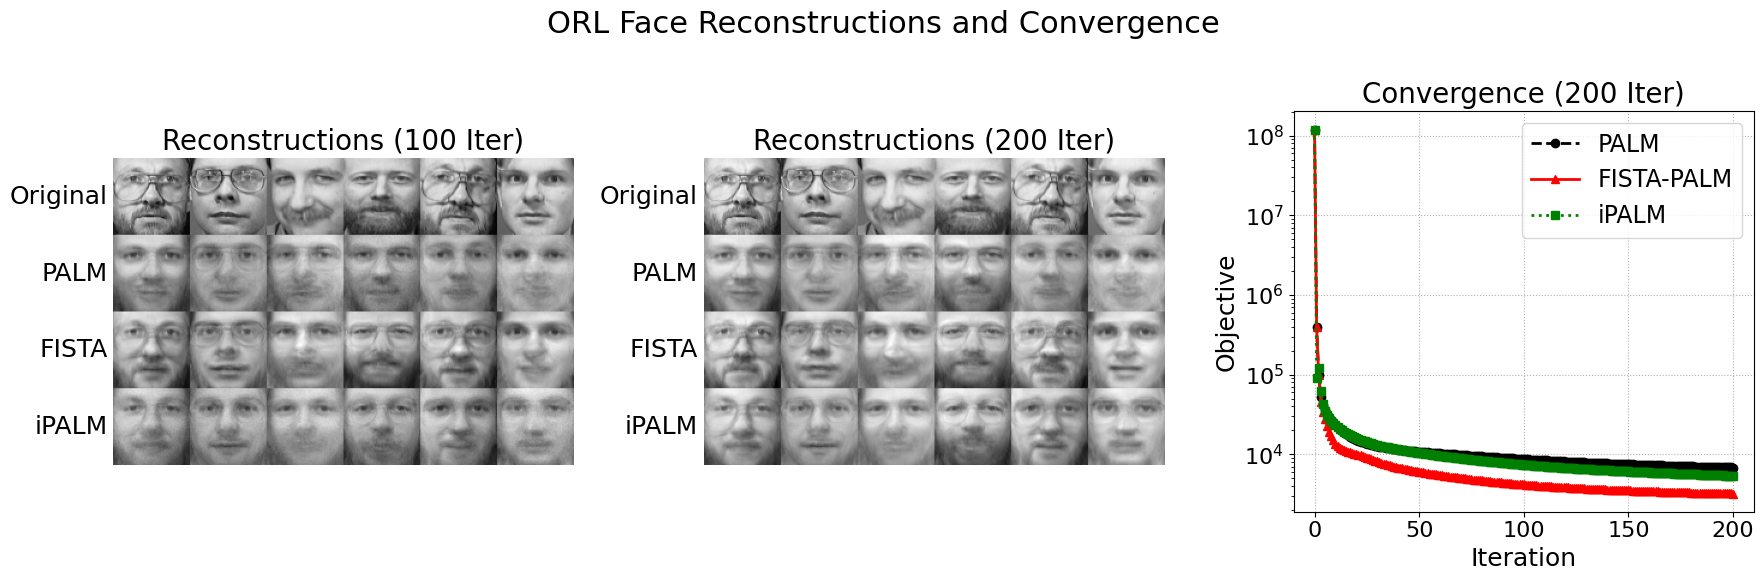

In [6]:
params = {
    "r": r,
    "s": sparsity,
    "iter": max_iter,
}

plot_orl_recon_and_loss(
    img_100,
    img_200,
    histories,
    row_labels=["Original", "PALM", "FISTA", "iPALM"],
    save_path=make_fig_path(ROOT, "orl_reconstruction_convergence", params),
)

In [7]:
df = pd.DataFrame(records)

save_table(
    df,
    ROOT,
    "orl_objective_summary",
    params,
)

df

,Method,Objective @ Iter 100,Objective @ Iter 200,Final Objective,Iterations
0,PALM,8686.894815,6812.315135,6812.315135,200
1,FISTA-PALM,4171.397570,3213.420722,3213.420722,200
2,iPALM,7398.929832,5361.662797,5361.662797,200


## Observations

- All three methods recover the main facial structure, but the reconstructions remain visibly smoothed due to the low-rank and sparsity constraints.

- FISTA-PALM gives the sharpest reconstructions, with clearer facial features around the eyes, nose, and mouth.

- PALM produces noticeably blurrier reconstructions, especially at $100$ iterations.

- iPALM improves over PALM visually in some faces, but its objective value remains higher than FISTA-PALM.

- The convergence curve confirms the visual result: FISTA-PALM reaches the lowest objective by both $100$ and $200$ iterations.

- Increasing from $100$ to $200$ iterations improves all methods, but the relative ordering remains the same:
  $$
  \text{FISTA-PALM} < \text{iPALM} < \text{PALM}
  $$
  in terms of final objective value.